# BetaVAE Beta Sweep Analysis
Train: 2013–2023 | Test: 2024–2026 | K=7 latent factors

Run `python scripts/run_beta_sweep.py` before opening this notebook.

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns

SWEEP   = next(p / "beta_sweep_k7" for p in [Path(".").resolve(), Path(".").resolve().parent] if (p / "beta_sweep_k7").exists())  # run from results/ or repo root
FACTORS = SWEEP / "factors"
ERRORS  = SWEEP / "errors"

assert ERRORS.exists(), (
    "No beta sweep data found. Run first:\n"
    "  python scripts/run_beta_sweep.py"
)

def _parse_beta(name):
    m = re.search(r"BetaVAE_b([\d.]+)", name)
    return float(m.group(1)) if m else None

# Auto-discover beta variants from saved CSVs
BETA_ARCHS = sorted(
    {f.stem.replace("_train_recon_error", "").replace("_test_recon_error", "")
     for f in ERRORS.glob("BetaVAE_b*_recon_error.csv")},
    key=_parse_beta,
)
BETAS = [_parse_beta(a) for a in BETA_ARCHS]
assert BETA_ARCHS, "No BetaVAE_b* CSV files found in beta_sweep/errors/"
print(f"Found {len(BETA_ARCHS)} beta variants: {BETAS}")

# Load recon errors
train_errors = {
    name: pd.read_csv(ERRORS / f"{name}_train_recon_error.csv", index_col=0, parse_dates=True)
    for name in BETA_ARCHS
}
test_errors = {
    name: pd.read_csv(ERRORS / f"{name}_test_recon_error.csv", index_col=0, parse_dates=True)
    for name in BETA_ARCHS
}

# Per-commodity MSE tables
def mse_table(errors_dict):
    rows = {}
    for name, err in errors_dict.items():
        per_com = (err ** 2).mean()
        per_com["ALL"] = float((err.to_numpy() ** 2).mean())
        rows[name] = per_com
    return pd.DataFrame(rows).T

train_mse_tbl = mse_table(train_errors)
test_mse_tbl  = mse_table(test_errors)

train_mses = [train_mse_tbl.loc[a, "ALL"] for a in BETA_ARCHS]
test_mses  = [test_mse_tbl.loc[a, "ALL"]  for a in BETA_ARCHS]

Found 8 beta variants: [0.3, 0.5, 0.8, 1.0, 2.0, 3.0, 4.0, 5.0]


## Summary Table

In [2]:
summary = pd.DataFrame({
    "beta":           BETAS,
    "train_recon_mse": train_mses,
    "test_recon_mse":  test_mses,
    "generalisation_gap": [t - r for r, t in zip(train_mses, test_mses)],
}, index=BETA_ARCHS)
display(summary.round(5))

,beta,train_recon_mse,test_recon_mse,generalisation_gap
BetaVAE_b0.3,0.3,0.65181,0.73747,0.08566
BetaVAE_b0.5,0.5,0.65550,0.74259,0.08709
BetaVAE_b0.8,0.8,0.66752,0.75945,0.09194
BetaVAE_b1,1.0,0.67856,0.77503,0.09647
BetaVAE_b2,2.0,0.73806,0.85757,0.11951
BetaVAE_b3,3.0,0.80916,0.96382,0.15466
BetaVAE_b4,4.0,0.83051,0.99219,0.16167
BetaVAE_b5,5.0,0.84888,1.00940,0.16052


## 1. Reconstruction MSE vs Beta

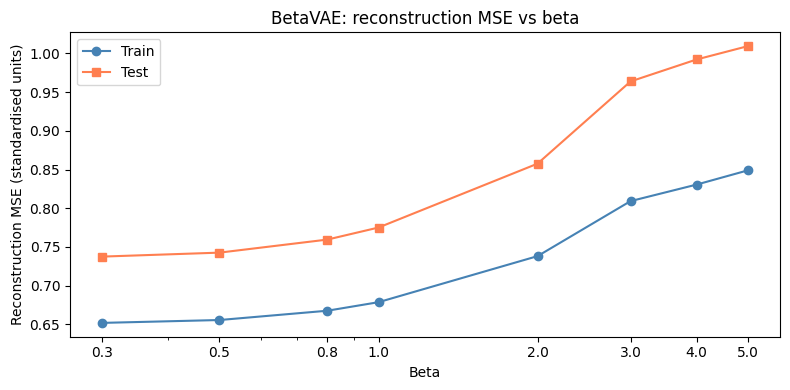

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(BETAS, train_mses, "o-", label="Train", color="steelblue")
ax.plot(BETAS, test_mses,  "s-", label="Test",  color="coral")
ax.set_xlabel("Beta")
ax.set_ylabel("Reconstruction MSE (standardised units)")
ax.set_title("BetaVAE: reconstruction MSE vs beta")
ax.set_xscale("log")
ax.set_xticks(BETAS)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend()
fig.tight_layout()
plt.show()

## 2. Generalisation Gap vs Beta

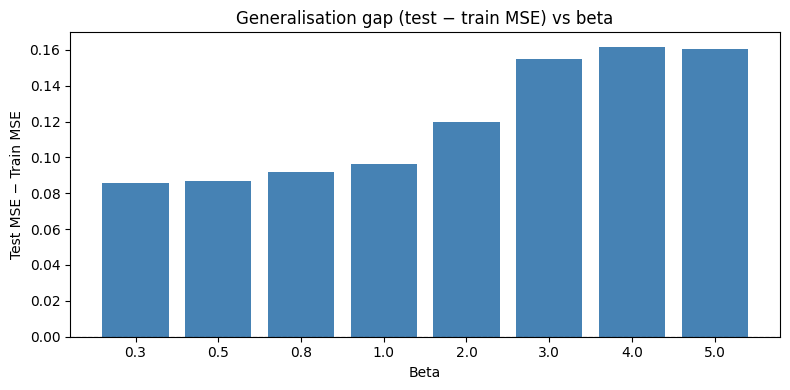

In [4]:
gaps = [t - r for r, t in zip(train_mses, test_mses)]
colors = ["steelblue" if g >= 0 else "crimson" for g in gaps]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(b) for b in BETAS], gaps, color=colors)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("Beta")
ax.set_ylabel("Test MSE − Train MSE")
ax.set_title("Generalisation gap (test − train MSE) vs beta")
fig.tight_layout()
plt.show()

## 3. Per-Commodity MSE Heatmap

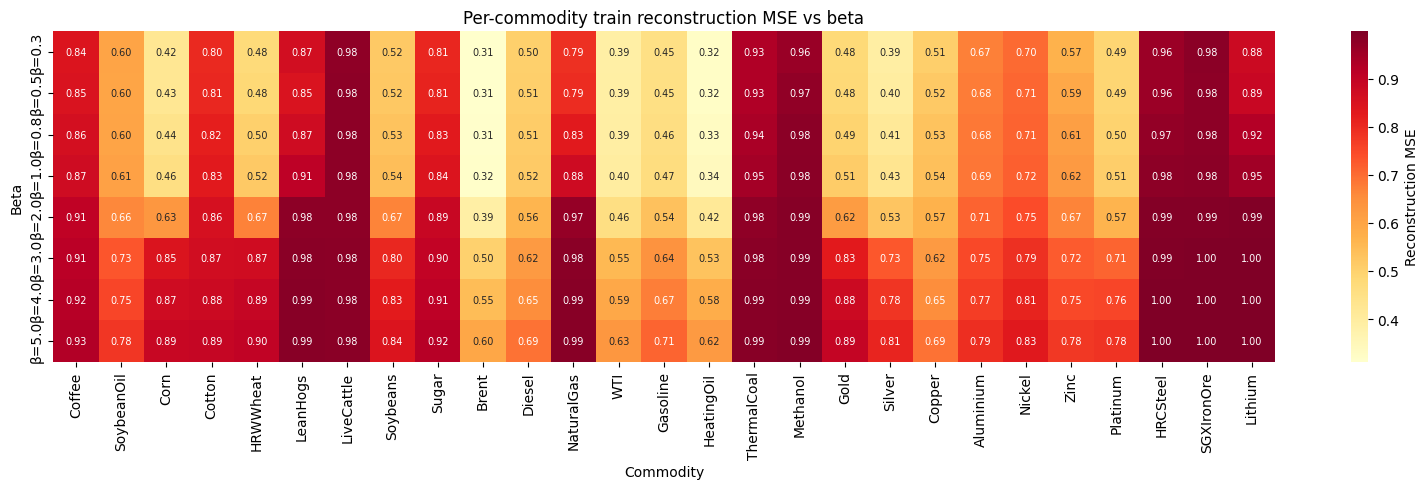

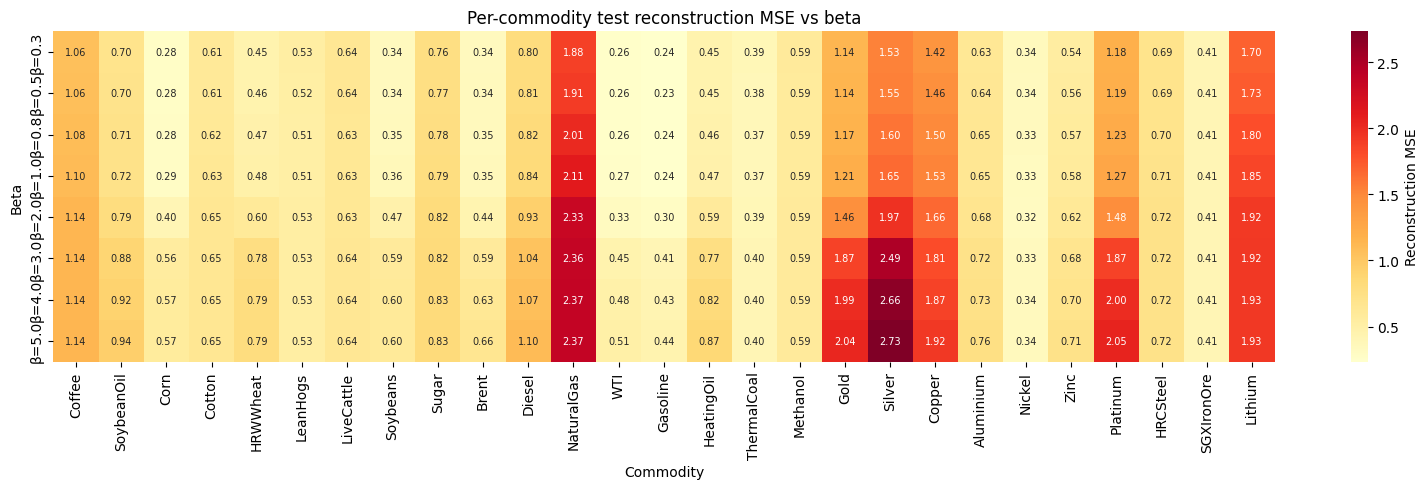

In [5]:
beta_labels = [f"β={b}" for b in BETAS]

for split, tbl in (("train", train_mse_tbl), ("test", test_mse_tbl)):
    data = tbl.drop(columns="ALL").rename(index=dict(zip(BETA_ARCHS, beta_labels)))
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(
        data, cmap="YlOrRd", annot=True, fmt=".2f",
        annot_kws={"size": 7}, cbar_kws={"label": "Reconstruction MSE"}, ax=ax,
    )
    ax.set_title(f"Per-commodity {split} reconstruction MSE vs beta")
    ax.set_xlabel("Commodity")
    ax.set_ylabel("Beta")
    fig.tight_layout()
    plt.show()

## 4. Factor Variances vs Beta

Low variance on a factor means the encoder has collapsed that dimension toward zero — the KL penalty at high beta forces the latent code toward the prior, killing information.

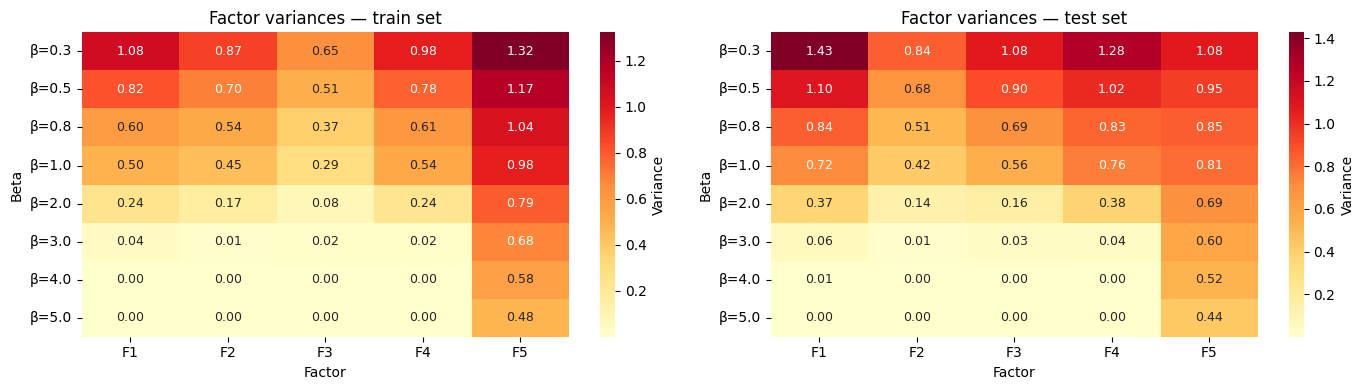

In [6]:
def load_factor_var(arch, split):
    return pd.read_csv(FACTORS / f"{arch}_{split}_factors.csv", index_col=0, parse_dates=True).var()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, split in zip(axes, ("train", "test")):
    var_matrix = pd.DataFrame(
        {f"β={b}": load_factor_var(a, split) for a, b in zip(BETA_ARCHS, BETAS)}
    ).T
    sns.heatmap(
        var_matrix, cmap="YlOrRd", annot=True, fmt=".2f",
        annot_kws={"size": 9}, ax=ax, cbar_kws={"label": "Variance"},
    )
    ax.set_title(f"Factor variances — {split} set")
    ax.set_xlabel("Factor")
    ax.set_ylabel("Beta")
fig.tight_layout()
plt.show()

## 5. Active Factor Count vs Beta

A factor is "active" if its variance exceeds a threshold (0.1). Shows how many dimensions the encoder uses at each beta.

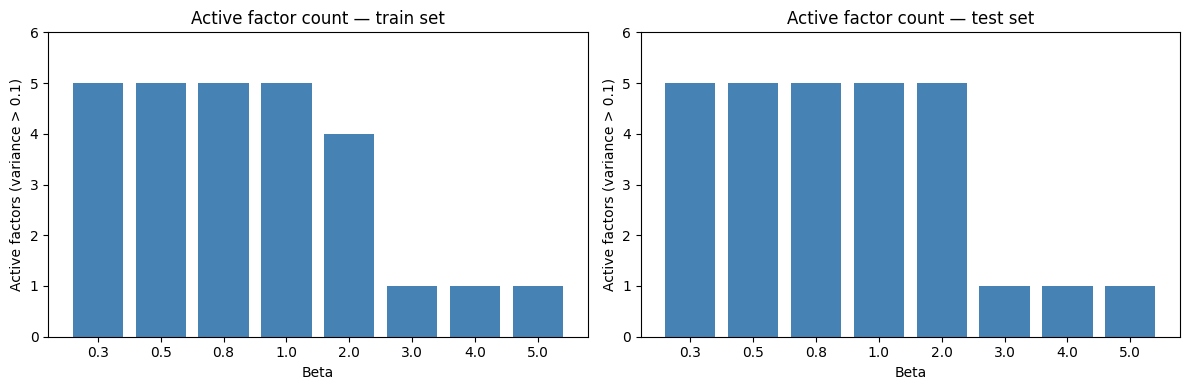

In [7]:
THRESHOLD = 0.1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, ("train", "test")):
    active_counts = [
        int((load_factor_var(a, split) > THRESHOLD).sum())
        for a in BETA_ARCHS
    ]
    ax.bar([str(b) for b in BETAS], active_counts, color="steelblue")
    ax.set_ylim(0, max(active_counts) + 1)
    ax.set_xlabel("Beta")
    ax.set_ylabel(f"Active factors (variance > {THRESHOLD})")
    ax.set_title(f"Active factor count — {split} set")
fig.tight_layout()
plt.show()

## 6. Factor Time Series

In [ ]:
for split in ("train", "test"):
    n = len(BETA_ARCHS)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, (arch, beta) in zip(axes, zip(BETA_ARCHS, BETAS)):
        factors = pd.read_csv(FACTORS / f"{arch}_{split}_factors.csv", index_col=0, parse_dates=True)
        for col in factors.columns:
            ax.plot(factors.index, factors[col], lw=0.8, alpha=0.8, label=col)
        ax.set_title(f"β={beta}")
        ax.set_ylabel("Factor value")
        ax.legend(loc="upper right", fontsize=7, ncol=5)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    year_range = "2013–2023" if split == "train" else "2024–2026"
    fig.suptitle(f"Latent factor time series — {split} set ({year_range})", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## 7. R² Explained per Beta

R² = 1 − MSE (valid because input is z-scored, so baseline variance = 1 per commodity).  
RMSE = √MSE.  
Higher β → stronger KL penalty → factors compressed toward prior → reconstruction worsens → lower R².

In [9]:
_SECTOR_MAP = {
    "Brent":"Energy","WTI":"Energy","NaturalGas":"Energy","Gasoline":"Energy",
    "Diesel":"Energy","HeatingOil":"Energy","ThermalCoal":"Energy","Methanol":"Energy",
    "Gold":"Metals","Silver":"Metals","Copper":"Metals","Aluminium":"Metals",
    "Nickel":"Metals","Zinc":"Metals","Platinum":"Metals","HRCSteel":"Metals",
    "SGXIronOre":"Metals","Lithium":"Metals",
    "Coffee":"Agriculture","Corn":"Agriculture","Cotton":"Agriculture",
    "LeanHogs":"Agriculture","LiveCattle":"Agriculture","Sugar":"Agriculture",
    "Soybeans":"Agriculture","SoybeanOil":"Agriculture","HRWWheat":"Agriculture",
}
_SECTOR_ORDER = ["Energy", "Metals", "Agriculture"]
beta_labels   = [f"β={b}" for b in BETAS]

def _metrics_df(mse_tbl):
    rows = []
    for arch in BETA_ARCHS:
        for com in mse_tbl.drop(columns="ALL").columns:
            mse = mse_tbl.loc[arch, com]
            rows.append({
                "beta_arch": arch,
                "commodity": com,
                "sector":    _SECTOR_MAP.get(com, "?"),
                "MSE":       mse,
                "RMSE":      np.sqrt(mse),
                "R2":        1.0 - mse,
            })
    return pd.DataFrame(rows)

train_metrics = _metrics_df(train_mse_tbl)
test_metrics  = _metrics_df(test_mse_tbl)

for label, df in [("Train (2013–2023)", train_metrics), ("Test (2024–2026)", test_metrics)]:
    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'═'*60}")

    overall = df.groupby("beta_arch")[["MSE","RMSE","R2"]].mean().loc[BETA_ARCHS]
    overall.index = beta_labels
    print("\n— Overall —")
    display(overall.round(4))

    sector_tbl = (
        df.groupby(["beta_arch","sector"])[["MSE","RMSE","R2"]]
        .mean()
        .unstack("sector")
        .loc[BETA_ARCHS]
        .reindex(columns=pd.MultiIndex.from_product([["MSE","RMSE","R2"], _SECTOR_ORDER]))
    )
    sector_tbl.index = beta_labels
    print("\n— Per sector —")
    display(sector_tbl.round(4))


════════════════════════════════════════════════════════════
  Train (2013–2023)
════════════════════════════════════════════════════════════

— Overall —


,MSE,RMSE,R2
β=0.3,0.6518,0.7955,0.3482
β=0.5,0.6555,0.7979,0.3445
β=0.8,0.6675,0.8054,0.3325
β=1.0,0.6786,0.8122,0.3214
β=2.0,0.7381,0.8509,0.2619
β=3.0,0.8092,0.8951,0.1908
β=4.0,0.8305,0.9078,0.1695
β=5.0,0.8489,0.9187,0.1511



— Per sector —


MSE                        RMSE                          R2          \
       Energy  Metals Agriculture  Energy  Metals Agriculture  Energy  Metals   
β=0.3  0.5827  0.6625      0.7013  0.7458  0.8047      0.8295  0.4173  0.3375   
β=0.5  0.5851  0.6695      0.7024  0.7472  0.8092      0.8304  0.4149  0.3305   
β=0.8  0.5951  0.6820      0.7158  0.7534  0.8171      0.8386  0.4049  0.3180   
β=1.0  0.6051  0.6922      0.7287  0.7595  0.8235      0.8464  0.3949  0.3078   
β=2.0  0.6616  0.7392      0.8047  0.7991  0.8538      0.8938  0.3384  0.2608   
β=3.0  0.7259  0.8140      0.8777  0.8437  0.8995      0.9360  0.2741  0.1860   
β=4.0  0.7511  0.8396      0.8910  0.8601  0.9141      0.9432  0.2489  0.1604   
β=5.0  0.7775  0.8575      0.9028  0.8768  0.9243      0.9496  0.2225  0.1425   

                   
      Agriculture  
β=0.3      0.2987  
β=0.5      0.2976  
β=0.8      0.2842  
β=1.0      0.2713  
β=2.0      0.1953  
β=3.0      0.1223  
β=4.0      0.1090  
β=5.0      0.0972


════════════════════════════════════════════════════════════
  Test (2024–2026)
════════════════════════════════════════════════════════════

— Overall —


,MSE,RMSE,R2
β=0.3,0.7375,0.8228,0.2625
β=0.5,0.7426,0.8248,0.2574
β=0.8,0.7595,0.8325,0.2405
β=1.0,0.7750,0.8399,0.2250
β=2.0,0.8576,0.8845,0.1424
β=3.0,0.9638,0.9384,0.0362
β=4.0,0.9922,0.9510,0.0078
β=5.0,1.0094,0.9590,-0.0094



— Per sector —


MSE                        RMSE                          R2          \
       Energy  Metals Agriculture  Energy  Metals Agriculture  Energy  Metals   
β=0.3  0.6172  0.9604      0.5967  0.7378  0.9481      0.7590  0.3828  0.0396   
β=0.5  0.6208  0.9706      0.5975  0.7387  0.9526      0.7593  0.3792  0.0294   
β=0.8  0.6378  0.9961      0.6046  0.7461  0.9633      0.7639  0.3622  0.0039   
β=1.0  0.6548  1.0175      0.6125  0.7539  0.9724      0.7691  0.3452 -0.0175   
β=2.0  0.7357  1.1235      0.6704  0.8036  1.0167      0.8096  0.2643 -0.1235   
β=3.0  0.8257  1.2829      0.7321  0.8637  1.0784      0.8494  0.1743 -0.2829   
β=4.0  0.8486  1.3345      0.7395  0.8777  1.0973      0.8536  0.1514 -0.3345   
β=5.0  0.8679  1.3617      0.7437  0.8893  1.1077      0.8558  0.1321 -0.3617   

                   
      Agriculture  
β=0.3      0.4033  
β=0.5      0.4025  
β=0.8      0.3954  
β=1.0      0.3875  
β=2.0      0.3296  
β=3.0      0.2679  
β=4.0      0.2605  
β=5.0      0.2563

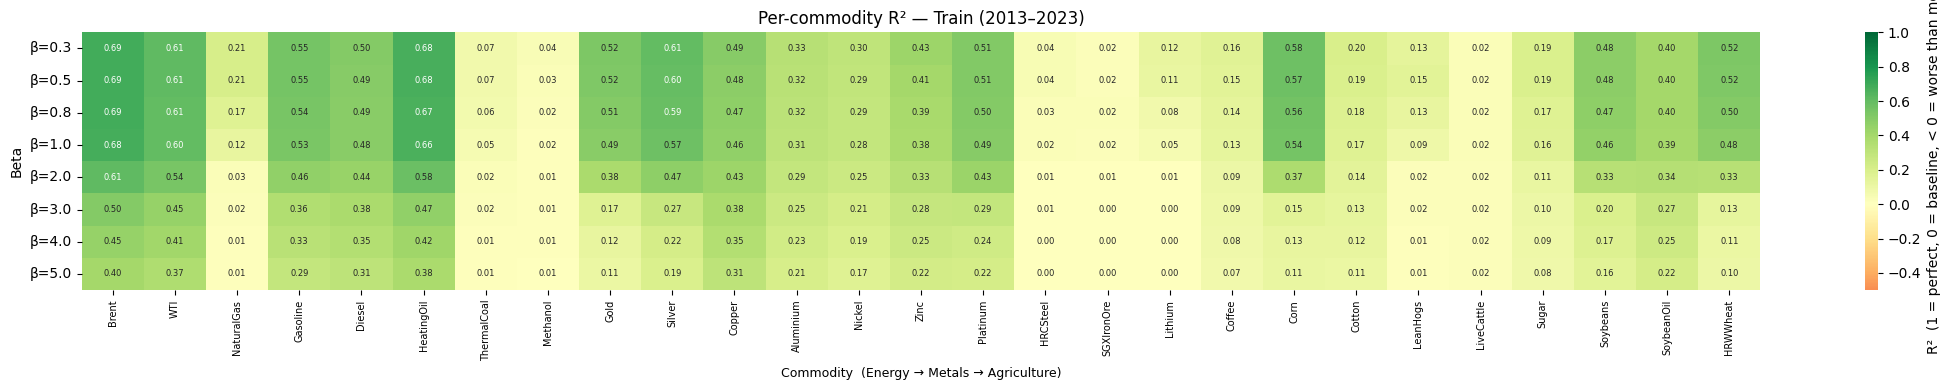

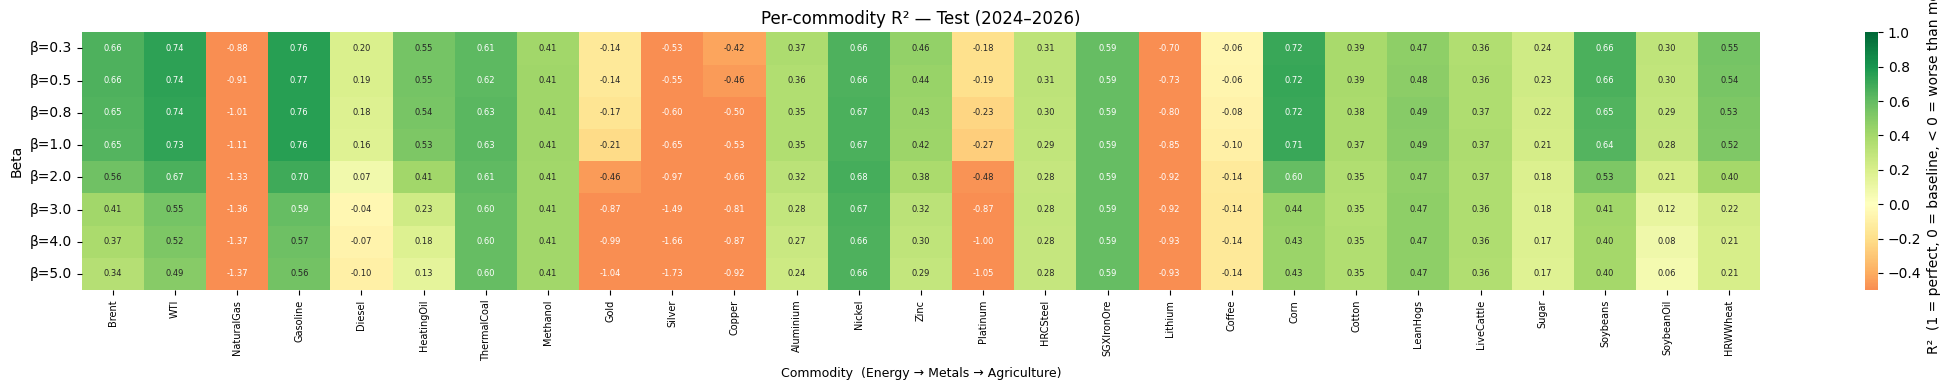

In [10]:
_COMMODITIES_ORDERED = sorted(
    _SECTOR_MAP,
    key=lambda c: (_SECTOR_ORDER.index(_SECTOR_MAP[c]), list(_SECTOR_MAP).index(c)),
)

for label, metrics in [("Train (2013–2023)", train_metrics), ("Test (2024–2026)", test_metrics)]:
    r2_wide = (
        metrics.pivot(index="beta_arch", columns="commodity", values="R2")
        .loc[BETA_ARCHS, _COMMODITIES_ORDERED]
    )
    r2_wide.index = beta_labels
    fig, ax = plt.subplots(figsize=(22, 4))
    sns.heatmap(
        r2_wide,
        cmap="RdYlGn", center=0, vmin=-0.5, vmax=1.0,
        annot=True, fmt=".2f", annot_kws={"size": 6},
        cbar_kws={"label": "R²  (1 = perfect, 0 = baseline, < 0 = worse than mean)"},
        ax=ax,
    )
    ax.set_title(f"Per-commodity R² — {label}", fontsize=12)
    ax.set_xlabel("Commodity  (Energy → Metals → Agriculture)", fontsize=9)
    ax.set_ylabel("Beta")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    fig.tight_layout()
    plt.show()

## 8. Factor Correlation Heatmaps

In [ ]:
n = len(BETA_ARCHS)
ncols = 2
nrows = (n + 1) // ncols

for split in ("train", "test"):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    axes = axes.flatten()
    for ax, (arch, beta) in zip(axes, zip(BETA_ARCHS, BETAS)):
        factors = pd.read_csv(FACTORS / f"{arch}_{split}_factors.csv", index_col=0, parse_dates=True)
        sns.heatmap(
            factors.corr(), ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8}, square=True, cbar=False,
        )
        ax.set_title(f"β={beta}")
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle(f"Factor cross-correlations — {split} set", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## 9. Latent Factor Interpretation

For each beta value, we compute the **correlation between each latent factor and each commodity return** — the autoencoder equivalent of PCA loadings. Higher β values are expected to produce more disentangled but less commodity-specific factors as the KL penalty pushes the posterior toward a structureless prior.

In [12]:
returns_raw = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)

SECTOR_MAP = {
    "Brent":"Energy","WTI":"Energy","NaturalGas":"Energy","Gasoline":"Energy",
    "Diesel":"Energy","HeatingOil":"Energy","ThermalCoal":"Energy","Methanol":"Energy",
    "Gold":"Metals","Silver":"Metals","Copper":"Metals","Aluminium":"Metals",
    "Nickel":"Metals","Zinc":"Metals","Platinum":"Metals","HRCSteel":"Metals",
    "SGXIronOre":"Metals","Lithium":"Metals",
    "Coffee":"Agriculture","Corn":"Agriculture","Cotton":"Agriculture",
    "LeanHogs":"Agriculture","LiveCattle":"Agriculture","Sugar":"Agriculture",
    "Soybeans":"Agriculture","SoybeanOil":"Agriculture","HRWWheat":"Agriculture",
}
SECTOR_ORDER = ["Energy", "Metals", "Agriculture"]
COMMODITIES_ORDERED = sorted(
    SECTOR_MAP, key=lambda c: (SECTOR_ORDER.index(SECTOR_MAP[c]), list(SECTOR_MAP).index(c))
)

def factor_commodity_corr(arch, split):
    factors = pd.read_csv(FACTORS / f"{arch}_{split}_factors.csv", index_col=0, parse_dates=True)
    rets    = returns_raw.reindex(factors.index)[COMMODITIES_ORDERED]
    return pd.DataFrame(
        {col: factors.corrwith(rets[col]) for col in rets.columns},
        index=factors.columns,
    )

### 9a. Factor–commodity correlation heatmaps (train then test)

In [ ]:
for split in ("train", "test"):
    nb = len(BETA_ARCHS)
    fig, axes = plt.subplots(nb, 1, figsize=(24, 4 * nb))
    if nb == 1:
        axes = [axes]
    for ax, (arch, beta) in zip(axes, zip(BETA_ARCHS, BETAS)):
        corr = factor_commodity_corr(arch, split)
        sns.heatmap(
            corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6},
            xticklabels=corr.columns, yticklabels=corr.index, cbar=True,
            cbar_kws={"label": "Correlation", "shrink": 0.6},
        )
        ax.set_title(f"β={beta}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Commodity  (Energy → Metals → Agriculture)", fontsize=8)
        ax.set_ylabel("Factor", fontsize=8)
        ax.tick_params(axis="x", rotation=90, labelsize=6)
        ax.tick_params(axis="y", rotation=0,  labelsize=8)
    year = "2013–2023" if split == "train" else "2024–2026"
    fig.suptitle(f"Factor–commodity correlation — {split} set ({year})", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### 9b. Top commodities per factor (train, by absolute correlation)

In [14]:
TOP_N = 5
for arch, beta in zip(BETA_ARCHS, BETAS):
    corr = factor_commodity_corr(arch, "train")
    rows = []
    for factor in corr.index:
        top = corr.loc[factor].abs().nlargest(TOP_N)
        for rank, (com, _) in enumerate(top.items(), 1):
            rows.append({
                "factor":      factor,
                "rank":        rank,
                "commodity":   com,
                "sector":      SECTOR_MAP[com],
                "correlation": round(corr.loc[factor, com], 3),
            })
    tbl = pd.DataFrame(rows).set_index(["factor", "rank"])
    print(f"\n{'─' * 60}")
    print(f"  β={beta} — top {TOP_N} commodities per factor (train, |corr|)")
    print(f"{'─' * 60}")
    display(tbl)


────────────────────────────────────────────────────────────
  β=0.3 — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


commodity       sector  correlation
factor rank                                      
F1     1           Gold       Metals       -0.559
       2         Silver       Metals       -0.533
       3           Corn  Agriculture        0.431
       4       Platinum       Metals       -0.428
       5       HRWWheat  Agriculture        0.408
F2     1           Corn  Agriculture       -0.524
       2       HRWWheat  Agriculture       -0.497
       3       Soybeans  Agriculture       -0.418
       4           Zinc       Metals        0.329
       5         Copper       Metals        0.306
F3     1         Silver       Metals       -0.751
       2       Platinum       Metals       -0.731
       3           Gold       Metals       -0.674
       4         Copper       Metals       -0.581
       5           Zinc       Metals       -0.580
F4     1         Silver       Metals       -0.511
       2           Gold       Metals       -0.449
       3       Platinum       Metals       -0.414
       4           Zinc       Metals       -0.397
       5         Copper       Metals       -0.394
F5     1          Brent       Energy       -0.790
       2     HeatingOil       Energy       -0.765
       3            WTI       Energy       -0.746
       4         Diesel       Energy       -0.680
       5       Gasoline       Energy       -0.672


────────────────────────────────────────────────────────────
  β=0.5 — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


commodity       sector  correlation
factor rank                                      
F1     1           Gold       Metals       -0.564
       2         Silver       Metals       -0.536
       3       Platinum       Metals       -0.428
       4           Corn  Agriculture        0.423
       5       HRWWheat  Agriculture        0.403
F2     1           Corn  Agriculture       -0.551
       2       HRWWheat  Agriculture       -0.515
       3       Soybeans  Agriculture       -0.454
       4     SoybeanOil  Agriculture       -0.290
       5           Zinc       Metals        0.287
F3     1         Silver       Metals       -0.755
       2       Platinum       Metals       -0.722
       3           Gold       Metals       -0.700
       4           Zinc       Metals       -0.511
       5         Copper       Metals       -0.507
F4     1         Silver       Metals       -0.494
       2           Gold       Metals       -0.432
       3       Platinum       Metals       -0.395
       4           Zinc       Metals       -0.385
       5           Corn  Agriculture       -0.384
F5     1          Brent       Energy       -0.786
       2     HeatingOil       Energy       -0.758
       3            WTI       Energy       -0.742
       4         Diesel       Energy       -0.679
       5       Gasoline       Energy       -0.669


────────────────────────────────────────────────────────────
  β=0.8 — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


...

commodity       sector  correlation
factor rank                                      
F1     1           Gold       Metals       -0.654
       2         Silver       Metals       -0.601
       3       Platinum       Metals       -0.471
       4           Corn  Agriculture        0.426
       5       HRWWheat  Agriculture        0.369
F2     1       HRWWheat  Agriculture       -0.583
       2           Corn  Agriculture       -0.576
       3       Soybeans  Agriculture       -0.553
       4     SoybeanOil  Agriculture       -0.511
       5           Gold       Metals       -0.356
F3     1           Gold       Metals       -0.626
       2         Silver       Metals       -0.610
       3       Platinum       Metals       -0.444
       4     HeatingOil       Energy        0.431
       5          Brent       Energy        0.411
F4     1         Silver       Metals       -0.644
       2           Gold       Metals       -0.588
       3       Platinum       Metals       -0.584
       4           Zinc       Metals       -0.491
       5         Copper       Metals       -0.459
F5     1          Brent       Energy       -0.750
       2     HeatingOil       Energy       -0.713
       3            WTI       Energy       -0.708
       4         Diesel       Energy       -0.657
       5         Copper       Metals       -0.637


────────────────────────────────────────────────────────────
  β=4.0 — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


commodity       sector  correlation
factor rank                                      
F1     1           Gold       Metals       -0.513
       2           Corn  Agriculture        0.482
       3         Silver       Metals       -0.430
       4       HRWWheat  Agriculture        0.424
       5       Soybeans  Agriculture        0.364
F2     1           Gold       Metals       -0.596
       2         Silver       Metals       -0.486
       3     SoybeanOil  Agriculture       -0.390
       4       Platinum       Metals       -0.379
       5        Lithium       Metals       -0.328
F3     1     HeatingOil       Energy        0.480
       2         Diesel       Energy        0.477
       3          Brent       Energy        0.465
       4            WTI       Energy        0.450
       5           Gold       Metals       -0.412
F4     1           Zinc       Metals       -0.641
       2         Copper       Metals       -0.563
       3         Nickel       Metals       -0.563
       4       Platinum       Metals       -0.494
       5         Silver       Metals       -0.444
F5     1          Brent       Energy       -0.749
       2     HeatingOil       Energy       -0.712
       3            WTI       Energy       -0.707
       4         Diesel       Energy       -0.655
       5         Copper       Metals       -0.638


────────────────────────────────────────────────────────────
  β=5.0 — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


commodity       sector  correlation
factor rank                                      
F1     1           Corn  Agriculture        0.494
       2       HRWWheat  Agriculture        0.434
       3         Cotton  Agriculture        0.395
       4       Soybeans  Agriculture        0.389
       5     HeatingOil       Energy        0.340
F2     1           Gold       Metals       -0.531
       2         Silver       Metals       -0.360
       3        Lithium       Metals       -0.308
       4       Platinum       Metals       -0.269
       5     SGXIronOre       Metals       -0.220
F3     1         Diesel       Energy        0.391
       2          Sugar  Agriculture        0.331
       3     HeatingOil       Energy        0.323
       4            WTI       Energy        0.314
       5          Brent       Energy        0.314
F4     1           Zinc       Metals       -0.537
       2            WTI       Energy       -0.493
       3         Copper       Metals       -0.491
       4         Nickel       Metals       -0.465
       5         Diesel       Energy       -0.460
F5     1          Brent       Energy       -0.747
       2     HeatingOil       Energy       -0.711
       3            WTI       Energy       -0.706
       4         Diesel       Energy       -0.653
       5         Copper       Metals       -0.638

### 9c. Factor–sector alignment (mean |correlation| per sector)

In [ ]:
nb = len(BETA_ARCHS)
fig, axes = plt.subplots(nb, 1, figsize=(7, 3 * nb))
if nb == 1:
    axes = [axes]

for ax, (arch, beta) in zip(axes, zip(BETA_ARCHS, BETAS)):
    corr = factor_commodity_corr(arch, "train")
    alignment = pd.DataFrame({
        sector: corr[[c for c in COMMODITIES_ORDERED if SECTOR_MAP[c] == sector]].abs().mean(axis=1)
        for sector in SECTOR_ORDER
    })
    sns.heatmap(
        alignment, ax=ax, cmap="YlOrRd", vmin=0, vmax=0.6,
        annot=True, fmt=".2f", annot_kws={"size": 9}, cbar=False,
    )
    ax.set_title(f"β={beta}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Factor")
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Factor–sector alignment — mean |correlation| per sector (train)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 9d. Cross-beta factor agreement

Do different beta values discover the same 5 factors? Hungarian-algorithm matching on the 5×5 absolute-correlation matrix between any two beta's factor matrices. Score near 1 = same factors found; near 0 = completely different representations.

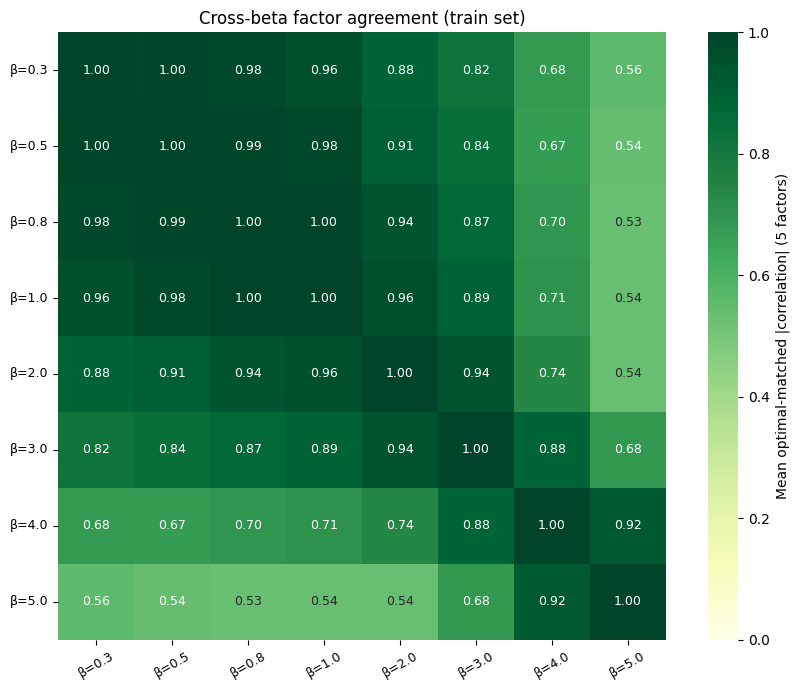

In [16]:
from scipy.optimize import linear_sum_assignment

def _factor_agreement(arch_a, arch_b, split="train"):
    fa = pd.read_csv(FACTORS / f"{arch_a}_{split}_factors.csv", index_col=0, parse_dates=True)
    fb = pd.read_csv(FACTORS / f"{arch_b}_{split}_factors.csv", index_col=0, parse_dates=True)
    common = fa.index.intersection(fb.index)
    fa, fb = fa.loc[common].to_numpy(), fb.loc[common].to_numpy()
    K = fa.shape[1]
    cost = np.array(
        [[abs(float(np.corrcoef(fa[:, i], fb[:, j])[0, 1])) for j in range(K)] for i in range(K)]
    )
    row, col = linear_sum_assignment(-cost)
    return float(cost[row, col].mean())

agree = pd.DataFrame(
    [[_factor_agreement(a, b) for b in BETA_ARCHS] for a in BETA_ARCHS],
    index=beta_labels, columns=beta_labels,
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    agree, ax=ax, cmap="YlGn", vmin=0, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 9}, square=True,
    cbar_kws={"label": "Mean optimal-matched |correlation| (5 factors)"},
)
ax.set_title("Cross-beta factor agreement (train set)", fontsize=12)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
fig.tight_layout()
plt.show()

### 9e. Factor autocorrelation — temporal persistence

Lag-1 (daily), lag-5 (weekly), lag-21 (monthly) autocorrelation per factor. High autocorrelation → slow macro regime signal. Near zero → fast noise. Watch for autocorrelation collapsing at high β as posterior collapse kills factor dynamics.

In [ ]:
LAGS = [1, 5, 21]

nb = len(BETA_ARCHS)
fig, axes = plt.subplots(nb, 1, figsize=(7, 3 * nb))
if nb == 1:
    axes = [axes]

for ax, (arch, beta) in zip(axes, zip(BETA_ARCHS, BETAS)):
    factors = pd.read_csv(FACTORS / f"{arch}_train_factors.csv", index_col=0, parse_dates=True)
    acorr = pd.DataFrame(
        {f"lag-{lag}d": factors.apply(lambda col: col.autocorr(lag=lag)) for lag in LAGS}
    )
    sns.heatmap(
        acorr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 9}, cbar=False,
    )
    ax.set_title(f"β={beta}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Factor")
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Factor autocorrelation (train) — temporal persistence", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 9f. Rolling factor–commodity correlation (stability)

252-day rolling correlation between each factor and its highest-correlated commodity. Stable lines = factor has a consistent economic interpretation across time. Drifting or flipping lines = the factor mixes signals, especially at high β.

In [ ]:
ROLL_WINDOW = 252

nb = len(BETA_ARCHS)
fig, axes = plt.subplots(nb, 1, figsize=(14, 3 * nb), sharex=True)
if nb == 1:
    axes = [axes]

for ax, (arch, beta) in zip(axes, zip(BETA_ARCHS, BETAS)):
    corr_full = factor_commodity_corr(arch, "train")
    factors   = pd.read_csv(FACTORS / f"{arch}_train_factors.csv", index_col=0, parse_dates=True)
    rets      = returns_raw.reindex(factors.index)
    for factor in corr_full.index:
        top_com = corr_full.loc[factor].abs().idxmax()
        rolling = factors[factor].rolling(ROLL_WINDOW).corr(rets[top_com])
        ax.plot(rolling.index, rolling, lw=0.9, alpha=0.85, label=f"{factor}↔{top_com}")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_ylim(-1, 1)
    ax.set_title(f"β={beta}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Rolling corr")
    ax.legend(loc="lower right", fontsize=6, ncol=5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle(f"Rolling {ROLL_WINDOW}-day factor↔top-commodity correlation (train)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 9g. Factor behaviour around market events

Factor time series with markers at key commodity market events. Compare how event sensitivity changes across beta values — high β models may show muted responses if factors are collapsed toward the prior.

In [ ]:
MARKET_EVENTS = {
    "COVID crash":      (pd.Timestamp("2020-03-20"), "red"),
    "COVID recovery":   (pd.Timestamp("2020-11-09"), "green"),
    "Russia-Ukraine":   (pd.Timestamp("2022-02-24"), "darkorange"),
    "Fed hike start":   (pd.Timestamp("2022-03-16"), "purple"),
    "Energy crisis pk": (pd.Timestamp("2022-08-26"), "steelblue"),
}

nb = len(BETA_ARCHS)
fig, axes = plt.subplots(nb, 1, figsize=(14, 3 * nb), sharex=True)
if nb == 1:
    axes = [axes]

for ax, (arch, beta) in zip(axes, zip(BETA_ARCHS, BETAS)):
    factors = pd.read_csv(FACTORS / f"{arch}_train_factors.csv", index_col=0, parse_dates=True)
    for col in factors.columns:
        ax.plot(factors.index, factors[col], lw=0.7, alpha=0.75, label=col)
    for ev_name, (ev_date, ev_col) in MARKET_EVENTS.items():
        if factors.index.min() <= ev_date <= factors.index.max():
            ax.axvline(ev_date, color=ev_col, lw=1.3, ls="--", alpha=0.9, label=ev_name)
    ax.set_title(f"β={beta}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Factor value")
    ax.legend(loc="upper right", fontsize=6, ncol=5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Factor behaviour around market events (train 2013–2023)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()